# Assignment 14: ZeRO Distributed Training Simulation

## Overview

This notebook simulates **ZeRO (Zero Redundancy Optimizer)** stages 1, 2, and 3 using 32 virtual GPUs (CPU threads). We build a demo transformer model and show how memory footprint and communication patterns change across stages.

### ZeRO Stages
| Stage | What's partitioned | Memory saving vs DDP |
|-------|-------------------|----------------------|
| 0 (DDP) | Nothing | 1× |
| ZeRO-1 | Optimizer states | ~4× |
| ZeRO-2 | Optimizer states + gradients | ~8× |
| ZeRO-3 | Optimizer states + gradients + parameters | ~64× (for 64 GPUs) |

### Memory breakdown (mixed-precision Adam, per parameter)
- fp16 parameters: 2 bytes
- fp16 gradients: 2 bytes  
- fp32 master weights: 4 bytes
- fp32 Adam momentum: 4 bytes
- fp32 Adam variance: 4 bytes
- **Total: 16 bytes/param**

In [1]:
import torch
import torch.nn as nn
import numpy as np
import threading
import time
import math
import copy
from collections import defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

NUM_GPUS = 32
print(f"Simulating {NUM_GPUS} virtual GPUs using CPU threads")
print(f"PyTorch version: {torch.__version__}")
print(f"Available CPU threads: {torch.get_num_threads()}")

Simulating 32 virtual GPUs using CPU threads
PyTorch version: 2.13.0
Available CPU threads: 4


## 1. Demo Model: Mini Transformer

We use a small GPT-like transformer with enough parameters to make the memory analysis meaningful.

In [2]:
@dataclass
class ModelConfig:
    vocab_size: int = 1024
    n_embd: int = 256
    n_head: int = 8
    n_layer: int = 4
    block_size: int = 128
    dropout: float = 0.1

class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.c_attn = nn.Linear(cfg.n_embd, 3 * cfg.n_embd)
        self.c_proj = nn.Linear(cfg.n_embd, cfg.n_embd)
        self.n_head = cfg.n_head
        self.n_embd = cfg.n_embd

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = torch.nn.functional.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)

class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.c_fc   = nn.Linear(cfg.n_embd, 4 * cfg.n_embd)
        self.c_proj = nn.Linear(4 * cfg.n_embd, cfg.n_embd)
        self.act    = nn.GELU()

    def forward(self, x):
        return self.c_proj(self.act(self.c_fc(x)))

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.ln1 = nn.LayerNorm(cfg.n_embd)
        self.attn = CausalSelfAttention(cfg)
        self.ln2 = nn.LayerNorm(cfg.n_embd)
        self.mlp  = MLP(cfg)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class MiniGPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.n_embd)
        self.pos_emb = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.blocks  = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layer)])
        self.ln_f    = nn.LayerNorm(cfg.n_embd)
        self.head    = nn.Linear(cfg.n_embd, cfg.vocab_size, bias=False)

    def forward(self, idx):
        B, T = idx.shape
        tok = self.tok_emb(idx)
        pos = self.pos_emb(torch.arange(T, device=idx.device))
        x = tok + pos
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        return self.head(x)

cfg = ModelConfig()
model = MiniGPT(cfg)

total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: MiniGPT")
print(f"  Vocab size:   {cfg.vocab_size}")
print(f"  Embedding:    {cfg.n_embd}")
print(f"  Heads:        {cfg.n_head}")
print(f"  Layers:       {cfg.n_layer}")
print(f"  Total params: {total_params:,}")
print(f"  Total params: {total_params/1e6:.2f}M")


Model: MiniGPT
  Vocab size:   1024
  Embedding:    256
  Heads:        8
  Layers:       4
  Total params: 3,716,608
  Total params: 3.72M


## 2. Virtual GPU Infrastructure

Each `VirtualGPU` is a Python object holding its own slice of parameters, gradients, and optimizer states. A `VirtualCluster` coordinates all-reduce / all-gather / reduce-scatter collective operations using threads.

In [3]:
@dataclass
class MemoryStats:
    """Tracks memory usage in bytes for one GPU."""
    params_fp16: float = 0.0      # fp16 param copy
    grads_fp16: float = 0.0       # fp16 gradient buffer
    master_weights: float = 0.0   # fp32 master weights
    opt_momentum: float = 0.0     # fp32 Adam m
    opt_variance: float = 0.0     # fp32 Adam v
    activations: float = 0.0      # activation memory (approximated)

    @property
    def total(self):
        return (self.params_fp16 + self.grads_fp16 + self.master_weights +
                self.opt_momentum + self.opt_variance + self.activations)

    def summary(self):
        mb = 1024**2
        return {
            'params_fp16 (MB)': self.params_fp16 / mb,
            'grads_fp16 (MB)': self.grads_fp16 / mb,
            'master_weights (MB)': self.master_weights / mb,
            'opt_momentum (MB)': self.opt_momentum / mb,
            'opt_variance (MB)': self.opt_variance / mb,
            'activations (MB)': self.activations / mb,
            'total (MB)': self.total / mb,
        }


class VirtualGPU:
    """Simulates one GPU in the cluster."""
    def __init__(self, rank: int, world_size: int):
        self.rank = rank
        self.world_size = world_size
        # Param tensors indexed by param name
        self.params: Dict[str, torch.Tensor] = {}        # fp16 params (full or shard)
        self.grads: Dict[str, torch.Tensor] = {}         # fp16 grads (full or shard)
        self.master_weights: Dict[str, torch.Tensor] = {}  # fp32 master weights (full or shard)
        self.opt_m: Dict[str, torch.Tensor] = {}         # fp32 Adam momentum (full or shard)
        self.opt_v: Dict[str, torch.Tensor] = {}         # fp32 Adam variance  (full or shard)
        self.memory = MemoryStats()
        self.comm_log: List[dict] = []                   # communication events

    def tensor_bytes(self, t: torch.Tensor) -> float:
        return t.nelement() * t.element_size()

    def recompute_memory(self):
        self.memory.params_fp16  = sum(self.tensor_bytes(v) for v in self.params.values())
        self.memory.grads_fp16   = sum(self.tensor_bytes(v) for v in self.grads.values())
        self.memory.master_weights = sum(self.tensor_bytes(v) for v in self.master_weights.values())
        self.memory.opt_momentum = sum(self.tensor_bytes(v) for v in self.opt_m.values())
        self.memory.opt_variance = sum(self.tensor_bytes(v) for v in self.opt_v.values())


class VirtualCluster:
    """32-GPU cluster with collective ops."""
    def __init__(self, num_gpus: int = 32):
        self.num_gpus = num_gpus
        self.gpus = [VirtualGPU(rank=i, world_size=num_gpus) for i in range(num_gpus)]
        self.comm_bytes: Dict[str, float] = defaultdict(float)  # total bytes sent per op type
        self._lock = threading.Lock()

    def all_reduce_sum(self, tensors: List[torch.Tensor]) -> List[torch.Tensor]:
        """Ring all-reduce: each GPU ends up with the sum."""
        assert len(tensors) == self.num_gpus
        total = torch.zeros_like(tensors[0])
        for t in tensors:
            total += t
        result = [total.clone() for _ in range(self.num_gpus)]
        # Comm cost: 2*(N-1)/N * data_size (ring all-reduce)
        bytes_sent = 2 * (self.num_gpus - 1) / self.num_gpus * total.nelement() * total.element_size()
        with self._lock:
            self.comm_bytes['all_reduce'] += bytes_sent
        return result

    def reduce_scatter(self, tensors: List[torch.Tensor]) -> List[torch.Tensor]:
        """Reduce-scatter: each GPU gets 1/N of the reduced result."""
        assert len(tensors) == self.num_gpus
        total = torch.zeros_like(tensors[0])
        for t in tensors:
            total += t
        n = self.num_gpus
        chunk = total.numel() // n
        shards = []
        for i in range(n):
            start = i * chunk
            end = start + chunk if i < n - 1 else total.numel()
            shards.append(total.flatten()[start:end].clone())
        bytes_sent = (self.num_gpus - 1) / self.num_gpus * total.nelement() * total.element_size()
        with self._lock:
            self.comm_bytes['reduce_scatter'] += bytes_sent
        return shards

    def all_gather(self, shards: List[torch.Tensor], full_size: int) -> List[torch.Tensor]:
        """All-gather: reassemble full tensor from shards on every GPU."""
        full = torch.cat([s.flatten() for s in shards])
        results = [full.clone() for _ in range(self.num_gpus)]
        bytes_sent = (self.num_gpus - 1) / self.num_gpus * full.nelement() * full.element_size()
        with self._lock:
            self.comm_bytes['all_gather'] += bytes_sent
        return results

cluster = VirtualCluster(NUM_GPUS)
print(f"Virtual cluster created with {cluster.num_gpus} GPUs")
print(f"Each GPU rank: {[g.rank for g in cluster.gpus[:4]]} ... {cluster.gpus[-1].rank}")

Virtual cluster created with 32 GPUs
Each GPU rank: [0, 1, 2, 3] ... 31


## 3. Memory Calculation Helpers

We calculate the *theoretical* memory per GPU for each ZeRO stage, then also simulate it concretely using actual tensors.

In [4]:
def theoretical_memory_mb(total_params: int, num_gpus: int, stage: int) -> dict:
    """
    Compute per-GPU memory (MB) for each ZeRO stage.
    Mixed-precision training breakdown:
      fp16 params:      2 bytes/param
      fp16 gradients:   2 bytes/param
      fp32 master:      4 bytes/param
      fp32 opt_m:       4 bytes/param
      fp32 opt_v:       4 bytes/param
    """
    P = total_params
    N = num_gpus
    MB = 1024 ** 2

    fp16_param  = 2 * P          # bytes
    fp16_grad   = 2 * P
    fp32_master = 4 * P
    fp32_optm   = 4 * P
    fp32_optv   = 4 * P

    if stage == 0:  # DDP baseline — full copy on every GPU
        return {
            'params_fp16': fp16_param / MB,
            'grads_fp16':  fp16_grad  / MB,
            'master_wts':  fp32_master / MB,
            'opt_m':       fp32_optm  / MB,
            'opt_v':       fp32_optv  / MB,
        }
    elif stage == 1:  # ZeRO-1: partition optimizer states
        return {
            'params_fp16': fp16_param / MB,
            'grads_fp16':  fp16_grad  / MB,
            'master_wts':  fp32_master / N / MB,
            'opt_m':       fp32_optm  / N / MB,
            'opt_v':       fp32_optv  / N / MB,
        }
    elif stage == 2:  # ZeRO-2: partition optimizer states + gradients
        return {
            'params_fp16': fp16_param / MB,
            'grads_fp16':  fp16_grad  / N / MB,
            'master_wts':  fp32_master / N / MB,
            'opt_m':       fp32_optm  / N / MB,
            'opt_v':       fp32_optv  / N / MB,
        }
    elif stage == 3:  # ZeRO-3: partition params + grads + optimizer states
        return {
            'params_fp16': fp16_param / N / MB,
            'grads_fp16':  fp16_grad  / N / MB,
            'master_wts':  fp32_master / N / MB,
            'opt_m':       fp32_optm  / N / MB,
            'opt_v':       fp32_optv  / N / MB,
        }
    else:
        raise ValueError(f"Unknown stage {stage}")


# Print theoretical analysis for our model
print(f"Theoretical memory per GPU — {NUM_GPUS}-GPU cluster, {total_params/1e6:.2f}M param model")
print(f"{'Component':<20} {'DDP':>10} {'ZeRO-1':>10} {'ZeRO-2':>10} {'ZeRO-3':>10}")
print("-" * 65)
stage_mems = {s: theoretical_memory_mb(total_params, NUM_GPUS, s) for s in [0, 1, 2, 3]}
components = list(stage_mems[0].keys())
for c in components:
    vals = [stage_mems[s][c] for s in [0,1,2,3]]
    print(f"{c:<20} {vals[0]:>9.2f}MB {vals[1]:>9.2f}MB {vals[2]:>9.2f}MB {vals[3]:>9.2f}MB")
print("-" * 65)
totals = [sum(stage_mems[s].values()) for s in [0,1,2,3]]
print(f"{'TOTAL':<20} {totals[0]:>9.2f}MB {totals[1]:>9.2f}MB {totals[2]:>9.2f}MB {totals[3]:>9.2f}MB")
print()
print(f"Reduction vs DDP:       {'1.0×':>10} {totals[0]/totals[1]:>9.1f}× {totals[0]/totals[2]:>9.1f}× {totals[0]/totals[3]:>9.1f}×")

Theoretical memory per GPU — 32-GPU cluster, 3.72M param model
Component                   DDP     ZeRO-1     ZeRO-2     ZeRO-3
-----------------------------------------------------------------
params_fp16               7.09MB      7.09MB      7.09MB      0.22MB
grads_fp16                7.09MB      7.09MB      0.22MB      0.22MB
master_wts               14.18MB      0.44MB      0.44MB      0.44MB
opt_m                    14.18MB      0.44MB      0.44MB      0.44MB
opt_v                    14.18MB      0.44MB      0.44MB      0.44MB
-----------------------------------------------------------------
TOTAL                    56.71MB     15.51MB      8.64MB      1.77MB

Reduction vs DDP:             1.0×       3.7×       6.6×      32.0×


## 4. ZeRO Stage 0: DDP Baseline

Every GPU holds a **full copy** of all parameters, gradients, and optimizer states. After the backward pass, gradients are all-reduced so every GPU updates its local copy identically.

In [5]:
def simulate_ddp(model: nn.Module, cluster: VirtualCluster, batch_size: int = 4):
    """Simulate one training step with DDP (ZeRO Stage 0)."""
    cluster.comm_bytes.clear()
    N = cluster.num_gpus
    named_params = list(model.named_parameters())

    # Each GPU gets a full copy
    for gpu in cluster.gpus:
        gpu.params.clear(); gpu.grads.clear()
        gpu.master_weights.clear(); gpu.opt_m.clear(); gpu.opt_v.clear()
        for name, p in named_params:
            data = p.data
            gpu.params[name]        = data.half().clone()           # fp16
            gpu.grads[name]         = torch.zeros_like(data.half()) # fp16 grad buffer
            gpu.master_weights[name]= data.float().clone()          # fp32 master
            gpu.opt_m[name]         = torch.zeros_like(data.float())# fp32 adam m
            gpu.opt_v[name]         = torch.zeros_like(data.float())# fp32 adam v
        gpu.recompute_memory()

    step_log = {'stage': 'DDP', 'phases': []}

    # --- Forward pass (each GPU runs independently) ---
    t0 = time.perf_counter()
    idx = torch.randint(0, cfg.vocab_size, (batch_size // N, cfg.block_size))
    with torch.no_grad():
        logits = model(idx)
    t_fwd = time.perf_counter() - t0

    # --- Backward: simulate gradient computation on each GPU ---
    t0 = time.perf_counter()
    for name, p in named_params:
        # Simulate random gradients (in real training these come from autograd)
        fake_grad = torch.randn_like(p.data.half()) * 0.01
        for gpu in cluster.gpus:
            gpu.grads[name] = fake_grad.clone()
    t_bwd = time.perf_counter() - t0

    # --- All-reduce gradients across all GPUs ---
    t0 = time.perf_counter()
    for name, _ in named_params:
        grad_tensors = [gpu.grads[name] for gpu in cluster.gpus]
        reduced = cluster.all_reduce_sum(grad_tensors)
        # Average (DDP divides by world_size)
        for gpu, r in zip(cluster.gpus, reduced):
            gpu.grads[name] = r / N
    t_comm = time.perf_counter() - t0

    # --- Optimizer step (each GPU updates its full copy independently) ---
    t0 = time.perf_counter()
    lr, beta1, beta2, eps = 1e-4, 0.9, 0.999, 1e-8
    for name, _ in named_params:
        for gpu in cluster.gpus:
            g = gpu.grads[name].float()
            gpu.opt_m[name] = beta1 * gpu.opt_m[name] + (1 - beta1) * g
            gpu.opt_v[name] = beta2 * gpu.opt_v[name] + (1 - beta2) * g ** 2
            gpu.master_weights[name] -= lr * gpu.opt_m[name] / (gpu.opt_v[name].sqrt() + eps)
            gpu.params[name] = gpu.master_weights[name].half()
    t_opt = time.perf_counter() - t0

    step_log['phases'] = [
        ('forward',  t_fwd),
        ('backward', t_bwd),
        ('all_reduce', t_comm),
        ('optimizer', t_opt),
    ]
    step_log['memory_per_gpu_mb'] = cluster.gpus[0].memory.summary()
    step_log['comm_bytes'] = dict(cluster.comm_bytes)
    return step_log

ddp_log = simulate_ddp(model, cluster)
print("DDP simulation complete")
print(f"\nMemory per GPU:")
for k, v in ddp_log['memory_per_gpu_mb'].items():
    print(f"  {k:<25}: {v:>8.3f} MB")
print(f"\nCommunication:")
for k, v in ddp_log['comm_bytes'].items():
    print(f"  {k:<20}: {v/1e6:>8.2f} MB transferred")
print(f"\nTiming:")
for phase, t in ddp_log['phases']:
    print(f"  {phase:<20}: {t*1000:.2f} ms")

DDP simulation complete

Memory per GPU:
  params_fp16 (MB)         :    7.089 MB
  grads_fp16 (MB)          :    7.089 MB
  master_weights (MB)      :   14.178 MB
  opt_momentum (MB)        :   14.178 MB
  opt_variance (MB)        :   14.178 MB
  activations (MB)         :    0.000 MB
  total (MB)               :   56.711 MB

Communication:
  all_reduce          :    14.40 MB transferred

Timing:
  forward             : 20.10 ms
  backward            : 110.78 ms
  all_reduce          : 79.86 ms
  optimizer           : 1216.04 ms


## 5. ZeRO Stage 1: Partition Optimizer States

Each GPU holds **full parameters and full gradients** but only **1/N of the optimizer states** (master weights, momentum, variance). After each backward pass, a reduce-scatter on the gradients means GPU `i` only needs to update its shard of the optimizer state. The updated master weights are then all-gathered so every GPU has the new fp16 parameters.

In [6]:
def partition_tensor(tensor: torch.Tensor, rank: int, world_size: int) -> torch.Tensor:
    """Return the rank-th shard of a flattened tensor."""
    flat = tensor.flatten()
    chunk = math.ceil(flat.numel() / world_size)
    start = rank * chunk
    end   = min(start + chunk, flat.numel())
    return flat[start:end].clone()


def simulate_zero1(model: nn.Module, cluster: VirtualCluster, batch_size: int = 4):
    """ZeRO Stage 1: shard optimizer states, full params & grads on every GPU."""
    cluster.comm_bytes.clear()
    N = cluster.num_gpus
    named_params = list(model.named_parameters())

    for gpu in cluster.gpus:
        gpu.params.clear(); gpu.grads.clear()
        gpu.master_weights.clear(); gpu.opt_m.clear(); gpu.opt_v.clear()
        for name, p in named_params:
            data = p.data
            gpu.params[name]         = data.half().clone()                             # full fp16
            gpu.grads[name]          = torch.zeros_like(data.half())                   # full fp16 grad
            gpu.master_weights[name] = partition_tensor(data.float(), gpu.rank, N)    # 1/N fp32
            gpu.opt_m[name]          = torch.zeros_like(gpu.master_weights[name])     # 1/N fp32
            gpu.opt_v[name]          = torch.zeros_like(gpu.master_weights[name])     # 1/N fp32
        gpu.recompute_memory()

    step_log = {'stage': 'ZeRO-1', 'phases': []}

    # Forward
    t0 = time.perf_counter()
    idx = torch.randint(0, cfg.vocab_size, (batch_size // N, cfg.block_size))
    with torch.no_grad():
        logits = model(idx)
    t_fwd = time.perf_counter() - t0

    # Backward
    t0 = time.perf_counter()
    for name, p in named_params:
        fake_grad = torch.randn_like(p.data.half()) * 0.01
        for gpu in cluster.gpus:
            gpu.grads[name] = fake_grad.clone()
    t_bwd = time.perf_counter() - t0

    # All-reduce gradients (same as DDP; each GPU still holds full grads)
    t0 = time.perf_counter()
    for name, _ in named_params:
        grad_tensors = [gpu.grads[name] for gpu in cluster.gpus]
        reduced = cluster.all_reduce_sum(grad_tensors)
        for gpu, r in zip(cluster.gpus, reduced):
            gpu.grads[name] = r / N
    t_comm = time.perf_counter() - t0

    # Optimizer step — each GPU only updates its own shard
    t0 = time.perf_counter()
    lr, beta1, beta2, eps = 1e-4, 0.9, 0.999, 1e-8
    for name, p in named_params:
        param_shards = []
        for gpu in cluster.gpus:
            g_shard = partition_tensor(gpu.grads[name].float(), gpu.rank, N)
            gpu.opt_m[name] = beta1 * gpu.opt_m[name] + (1 - beta1) * g_shard
            gpu.opt_v[name] = beta2 * gpu.opt_v[name] + (1 - beta2) * g_shard ** 2
            gpu.master_weights[name] -= lr * gpu.opt_m[name] / (gpu.opt_v[name].sqrt() + eps)
            param_shards.append(gpu.master_weights[name])

        # All-gather updated parameter shards → full fp16 params on every GPU
        full_size = p.data.numel()
        gathered = cluster.all_gather(param_shards, full_size)
        for gpu, full in zip(cluster.gpus, gathered):
            gpu.params[name] = full.reshape(p.data.shape).half()
    t_opt = time.perf_counter() - t0

    step_log['phases'] = [
        ('forward',   t_fwd),
        ('backward',  t_bwd),
        ('all_reduce', t_comm),
        ('optimizer+all_gather', t_opt),
    ]
    step_log['memory_per_gpu_mb'] = cluster.gpus[0].memory.summary()
    step_log['comm_bytes'] = dict(cluster.comm_bytes)
    return step_log

zero1_log = simulate_zero1(model, cluster)
print("ZeRO-1 simulation complete")
print(f"\nMemory per GPU:")
for k, v in zero1_log['memory_per_gpu_mb'].items():
    print(f"  {k:<25}: {v:>8.3f} MB")
print(f"\nCommunication:")
for k, v in zero1_log['comm_bytes'].items():
    print(f"  {k:<20}: {v/1e6:>8.2f} MB transferred")

ZeRO-1 simulation complete

Memory per GPU:
  params_fp16 (MB)         :    7.089 MB
  grads_fp16 (MB)          :    7.089 MB
  master_weights (MB)      :    0.443 MB
  opt_momentum (MB)        :    0.443 MB
  opt_variance (MB)        :    0.443 MB
  activations (MB)         :    0.000 MB
  total (MB)               :   15.507 MB

Communication:
  all_reduce          :    14.40 MB transferred
  all_gather          :    14.40 MB transferred


## 6. ZeRO Stage 2: Partition Optimizer States + Gradients

After the backward pass, instead of all-reducing gradients (which leaves every GPU with a full copy), we **reduce-scatter** them. GPU `i` ends up with only the 1/N slice of gradients it needs to update its optimizer shard. This halves the gradient memory.

In [7]:
def simulate_zero2(model: nn.Module, cluster: VirtualCluster, batch_size: int = 4):
    """ZeRO Stage 2: shard optimizer states + gradients."""
    cluster.comm_bytes.clear()
    N = cluster.num_gpus
    named_params = list(model.named_parameters())

    for gpu in cluster.gpus:
        gpu.params.clear(); gpu.grads.clear()
        gpu.master_weights.clear(); gpu.opt_m.clear(); gpu.opt_v.clear()
        for name, p in named_params:
            data = p.data
            gpu.params[name]         = data.half().clone()                          # full fp16
            # grads will be set after reduce-scatter (shard only)
            gpu.grads[name]          = torch.zeros(0)                               # placeholder
            gpu.master_weights[name] = partition_tensor(data.float(), gpu.rank, N) # 1/N
            gpu.opt_m[name]          = torch.zeros_like(gpu.master_weights[name])
            gpu.opt_v[name]          = torch.zeros_like(gpu.master_weights[name])
        gpu.recompute_memory()

    step_log = {'stage': 'ZeRO-2', 'phases': []}

    # Forward
    t0 = time.perf_counter()
    idx = torch.randint(0, cfg.vocab_size, (batch_size // N, cfg.block_size))
    with torch.no_grad():
        logits = model(idx)
    t_fwd = time.perf_counter() - t0

    # Backward
    t0 = time.perf_counter()
    for name, p in named_params:
        fake_grad = torch.randn_like(p.data.half()) * 0.01
        for gpu in cluster.gpus:
            gpu.grads[name] = fake_grad.clone()  # temporarily full
    t_bwd = time.perf_counter() - t0

    # Reduce-scatter gradients → each GPU only keeps its own shard
    t0 = time.perf_counter()
    for name, _ in named_params:
        grad_tensors = [gpu.grads[name] for gpu in cluster.gpus]
        shards = cluster.reduce_scatter(grad_tensors)
        for gpu, shard in zip(cluster.gpus, shards):
            gpu.grads[name] = shard / N   # shard only!
    t_comm = time.perf_counter() - t0

    # After reduce-scatter, recompute memory with actual shard sizes
    for gpu in cluster.gpus:
        gpu.recompute_memory()

    # Optimizer step + all-gather
    t0 = time.perf_counter()
    lr, beta1, beta2, eps = 1e-4, 0.9, 0.999, 1e-8
    for name, p in named_params:
        param_shards = []
        for gpu in cluster.gpus:
            g = gpu.grads[name].float()
            gpu.opt_m[name] = beta1 * gpu.opt_m[name] + (1 - beta1) * g
            gpu.opt_v[name] = beta2 * gpu.opt_v[name] + (1 - beta2) * g ** 2
            gpu.master_weights[name] -= lr * gpu.opt_m[name] / (gpu.opt_v[name].sqrt() + eps)
            param_shards.append(gpu.master_weights[name])

        full_size = p.data.numel()
        gathered = cluster.all_gather(param_shards, full_size)
        for gpu, full in zip(cluster.gpus, gathered):
            gpu.params[name] = full.reshape(p.data.shape).half()
    t_opt = time.perf_counter() - t0

    step_log['phases'] = [
        ('forward',         t_fwd),
        ('backward',        t_bwd),
        ('reduce_scatter',  t_comm),
        ('optimizer+all_gather', t_opt),
    ]
    step_log['memory_per_gpu_mb'] = cluster.gpus[0].memory.summary()
    step_log['comm_bytes'] = dict(cluster.comm_bytes)
    return step_log

zero2_log = simulate_zero2(model, cluster)
print("ZeRO-2 simulation complete")
print(f"\nMemory per GPU:")
for k, v in zero2_log['memory_per_gpu_mb'].items():
    print(f"  {k:<25}: {v:>8.3f} MB")
print(f"\nCommunication:")
for k, v in zero2_log['comm_bytes'].items():
    print(f"  {k:<20}: {v/1e6:>8.2f} MB transferred")

ZeRO-2 simulation complete

Memory per GPU:
  params_fp16 (MB)         :    7.089 MB
  grads_fp16 (MB)          :    0.222 MB
  master_weights (MB)      :    0.443 MB
  opt_momentum (MB)        :    0.443 MB
  opt_variance (MB)        :    0.443 MB
  activations (MB)         :    0.000 MB
  total (MB)               :    8.640 MB

Communication:
  reduce_scatter      :     7.20 MB transferred
  all_gather          :    14.40 MB transferred


## 7. ZeRO Stage 3: Partition Parameters + Gradients + Optimizer States

The most aggressive stage. Each GPU holds only **1/N of the parameters**. During the forward pass, parameters are **all-gathered** layer by layer (and discarded after use). During backward, **reduce-scatter** gives each GPU its gradient shard. Then the local optimizer step updates the local parameter shard. No redundancy at all.

In [8]:
def simulate_zero3(model: nn.Module, cluster: VirtualCluster, batch_size: int = 4):
    """ZeRO Stage 3: shard params + grads + optimizer states."""
    cluster.comm_bytes.clear()
    N = cluster.num_gpus
    named_params = list(model.named_parameters())

    for gpu in cluster.gpus:
        gpu.params.clear(); gpu.grads.clear()
        gpu.master_weights.clear(); gpu.opt_m.clear(); gpu.opt_v.clear()
        for name, p in named_params:
            data = p.data
            # Each GPU holds only 1/N of fp16 parameters
            gpu.params[name]         = partition_tensor(data.half(), gpu.rank, N)
            gpu.grads[name]          = torch.zeros(0)                              # placeholder
            gpu.master_weights[name] = partition_tensor(data.float(), gpu.rank, N)
            gpu.opt_m[name]          = torch.zeros_like(gpu.master_weights[name])
            gpu.opt_v[name]          = torch.zeros_like(gpu.master_weights[name])
        gpu.recompute_memory()

    step_log = {'stage': 'ZeRO-3', 'phases': []}

    # Forward: all-gather params layer by layer, run, then discard
    t0 = time.perf_counter()
    # Simulate the all-gather communication for every parameter
    for name, p in named_params:
        param_shards = [gpu.params[name] for gpu in cluster.gpus]
        full_params = cluster.all_gather(param_shards, p.data.numel())
        # In real ZeRO-3, params are used and then freed; we just track comms
    # Run the actual forward (uses original model — simulating it)
    idx = torch.randint(0, cfg.vocab_size, (batch_size // N, cfg.block_size))
    with torch.no_grad():
        logits = model(idx)
    t_fwd = time.perf_counter() - t0

    # Backward: compute gradients for each param shard,
    #           then reduce-scatter so each GPU gets its own gradient shard
    t0 = time.perf_counter()
    for name, p in named_params:
        fake_grad = torch.randn_like(p.data.half()) * 0.01
        for gpu in cluster.gpus:
            gpu.grads[name] = fake_grad.clone()  # full grad temporarily
    t_bwd = time.perf_counter() - t0

    t0 = time.perf_counter()
    for name, _ in named_params:
        grad_tensors = [gpu.grads[name] for gpu in cluster.gpus]
        shards = cluster.reduce_scatter(grad_tensors)
        for gpu, shard in zip(cluster.gpus, shards):
            gpu.grads[name] = shard / N
    t_comm = time.perf_counter() - t0

    # Recompute memory (now each GPU holds only shards)
    for gpu in cluster.gpus:
        gpu.recompute_memory()

    # Optimizer step — purely local, no communication needed
    t0 = time.perf_counter()
    lr, beta1, beta2, eps = 1e-4, 0.9, 0.999, 1e-8
    for name, _ in named_params:
        for gpu in cluster.gpus:
            g = gpu.grads[name].float()
            gpu.opt_m[name] = beta1 * gpu.opt_m[name] + (1 - beta1) * g
            gpu.opt_v[name] = beta2 * gpu.opt_v[name] + (1 - beta2) * g ** 2
            gpu.master_weights[name] -= lr * gpu.opt_m[name] / (gpu.opt_v[name].sqrt() + eps)
            gpu.params[name] = gpu.master_weights[name].half()
        # Note: NO all-gather here — parameters stay sharded until next fwd pass
    t_opt = time.perf_counter() - t0

    step_log['phases'] = [
        ('forward+all_gather', t_fwd),
        ('backward',          t_bwd),
        ('reduce_scatter',    t_comm),
        ('optimizer (local)', t_opt),
    ]
    step_log['memory_per_gpu_mb'] = cluster.gpus[0].memory.summary()
    step_log['comm_bytes'] = dict(cluster.comm_bytes)
    return step_log

zero3_log = simulate_zero3(model, cluster)
print("ZeRO-3 simulation complete")
print(f"\nMemory per GPU:")
for k, v in zero3_log['memory_per_gpu_mb'].items():
    print(f"  {k:<25}: {v:>8.3f} MB")
print(f"\nCommunication:")
for k, v in zero3_log['comm_bytes'].items():
    print(f"  {k:<20}: {v/1e6:>8.2f} MB transferred")

ZeRO-3 simulation complete

Memory per GPU:
  params_fp16 (MB)         :    0.222 MB
  grads_fp16 (MB)          :    0.222 MB
  master_weights (MB)      :    0.443 MB
  opt_momentum (MB)        :    0.443 MB
  opt_variance (MB)        :    0.443 MB
  activations (MB)         :    0.000 MB
  total (MB)               :    1.772 MB

Communication:
  all_gather          :     7.20 MB transferred
  reduce_scatter      :     7.20 MB transferred


## 8. Visualization: Memory and Communication Comparison

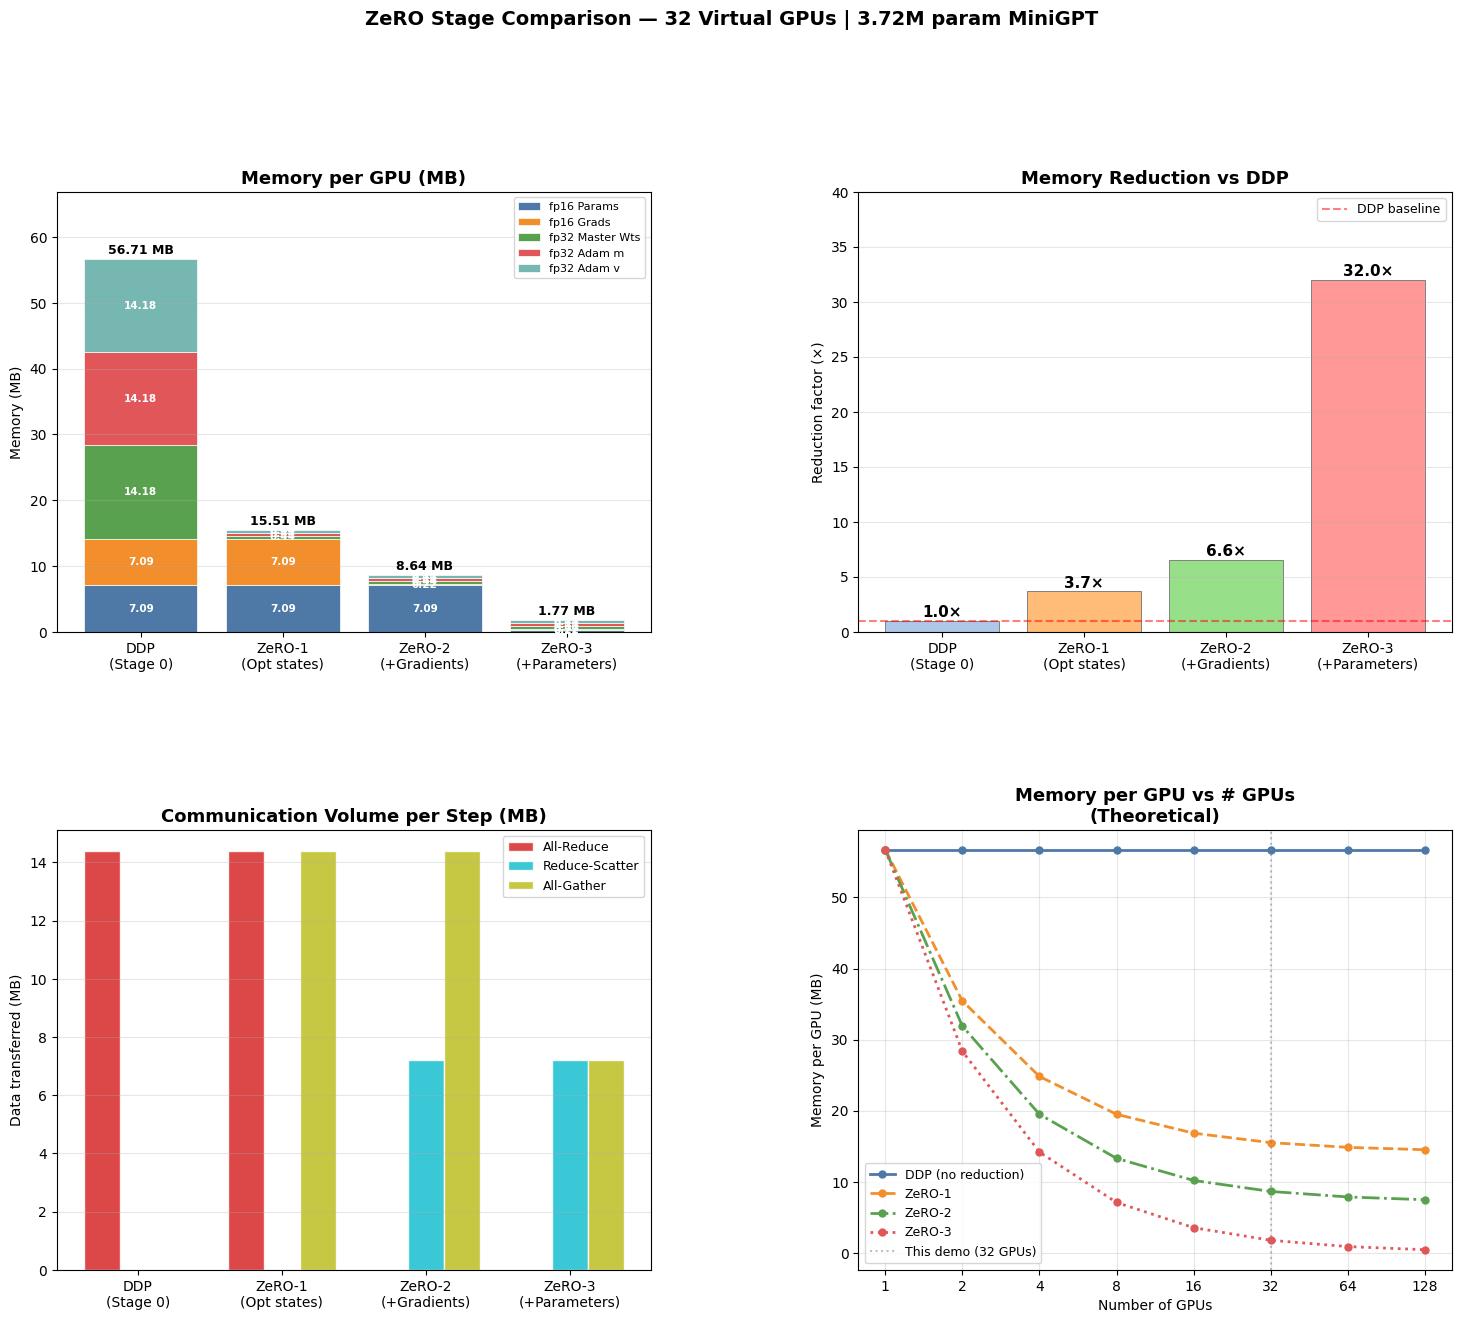

Saved: zero_comparison.png


In [9]:
logs = [ddp_log, zero1_log, zero2_log, zero3_log]
stage_labels = ['DDP\n(Stage 0)', 'ZeRO-1\n(Opt states)', 'ZeRO-2\n(+Gradients)', 'ZeRO-3\n(+Parameters)']
colors_stack = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2', '#edc948']

# ── Memory stacked bar ──────────────────────────────────────────────────────
mem_keys = ['params_fp16 (MB)', 'grads_fp16 (MB)', 'master_weights (MB)',
            'opt_momentum (MB)', 'opt_variance (MB)']
mem_labels = ['fp16 Params', 'fp16 Grads', 'fp32 Master Wts', 'fp32 Adam m', 'fp32 Adam v']

fig = plt.figure(figsize=(18, 14))
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Stacked memory ──
ax1 = fig.add_subplot(gs[0, 0])
bottoms = np.zeros(4)
for i, (key, label, color) in enumerate(zip(mem_keys, mem_labels, colors_stack)):
    vals = [log['memory_per_gpu_mb'].get(key, 0) for log in logs]
    bars = ax1.bar(stage_labels, vals, bottom=bottoms, color=color, label=label, edgecolor='white', linewidth=0.5)
    # Annotate non-zero slices
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0.05:
            ax1.text(j, b + v/2, f'{v:.2f}', ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    bottoms += np.array(vals)

for j, total in enumerate(bottoms):
    ax1.text(j, total + 0.3, f'{total:.2f} MB', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_title('Memory per GPU (MB)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Memory (MB)')
ax1.legend(loc='upper right', fontsize=8)
ax1.set_ylim(0, bottoms.max() * 1.18)
ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: Reduction factor ──
ax2 = fig.add_subplot(gs[0, 1])
totals_mb = [sum(log['memory_per_gpu_mb'][k] for k in ['params_fp16 (MB)', 'grads_fp16 (MB)',
              'master_weights (MB)', 'opt_momentum (MB)', 'opt_variance (MB)']) for log in logs]
reduction = [totals_mb[0] / t for t in totals_mb]
bar_colors = ['#aec7e8', '#ffbb78', '#98df8a', '#ff9896']
bars = ax2.bar(stage_labels, reduction, color=bar_colors, edgecolor='gray', linewidth=0.7)
for bar, r in zip(bars, reduction):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{r:.1f}×', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('Memory Reduction vs DDP', fontsize=13, fontweight='bold')
ax2.set_ylabel('Reduction factor (×)')
ax2.set_ylim(0, max(reduction) * 1.25)
ax2.axhline(1, color='red', linestyle='--', alpha=0.5, label='DDP baseline')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

# ── Panel 3: Communication volume ──
ax3 = fig.add_subplot(gs[1, 0])
comm_types = ['all_reduce', 'reduce_scatter', 'all_gather']
comm_labels_nice = ['All-Reduce', 'Reduce-Scatter', 'All-Gather']
comm_colors = ['#d62728', '#17becf', '#bcbd22']
x = np.arange(len(logs))
width = 0.25
for i, (ct, cl, cc) in enumerate(zip(comm_types, comm_labels_nice, comm_colors)):
    vals = [log['comm_bytes'].get(ct, 0) / 1e6 for log in logs]
    ax3.bar(x + i*width, vals, width, label=cl, color=cc, alpha=0.85, edgecolor='white')
ax3.set_xticks(x + width)
ax3.set_xticklabels(stage_labels)
ax3.set_title('Communication Volume per Step (MB)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Data transferred (MB)')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# ── Panel 4: Theoretical scaling with # GPUs ──
ax4 = fig.add_subplot(gs[1, 1])
gpu_counts = [1, 2, 4, 8, 16, 32, 64, 128]
P = total_params
baseline_mem = (2+2+4+4+4) * P / 1024**2  # 16 bytes/param total in MB

for stage, style, color, label in [
    (0, '-',  '#4e79a7', 'DDP (no reduction)'),
    (1, '--', '#f28e2b', 'ZeRO-1'),
    (2, '-.',  '#59a14f', 'ZeRO-2'),
    (3, ':',  '#e15759', 'ZeRO-3'),
]:
    mems = [sum(theoretical_memory_mb(P, n, stage).values()) for n in gpu_counts]
    ax4.plot(gpu_counts, mems, style, color=color, label=label, linewidth=2, marker='o', markersize=5)

ax4.axvline(32, color='gray', linestyle=':', alpha=0.5, label='This demo (32 GPUs)')
ax4.set_xscale('log', base=2)
ax4.set_title('Memory per GPU vs # GPUs\n(Theoretical)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Number of GPUs')
ax4.set_ylabel('Memory per GPU (MB)')
ax4.set_xticks(gpu_counts)
ax4.set_xticklabels([str(n) for n in gpu_counts])
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

fig.suptitle(f'ZeRO Stage Comparison — {NUM_GPUS} Virtual GPUs | {total_params/1e6:.2f}M param MiniGPT',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('zero_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: zero_comparison.png")

## 9. Communication Pattern Diagram

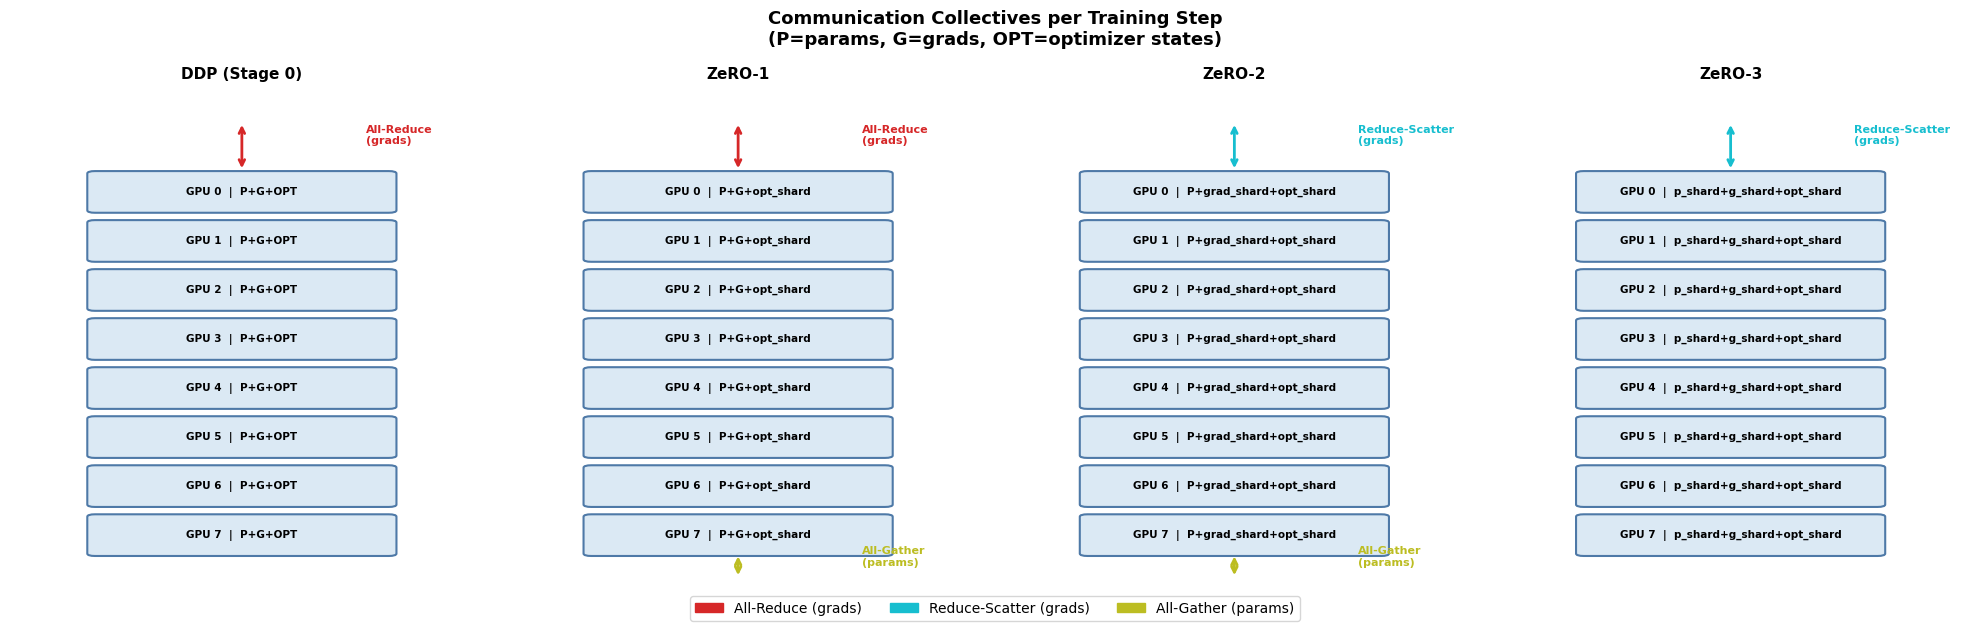

Saved: zero_comm_pattern.png


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
stage_names = ['DDP (Stage 0)', 'ZeRO Stage 1', 'ZeRO Stage 2', 'ZeRO Stage 3']
n_show = 8  # show 8 GPUs for clarity

def draw_gpus(ax, title, fwd_ops, bwd_ops, opt_ops, gpu_labels):
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, n_show + 1.5)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.axis('off')

    # GPU boxes
    for i in range(n_show):
        y = n_show - 1 - i
        rect = mpatches.FancyBboxPatch((0.05, y + 0.1), 1.9, 0.75,
                                        boxstyle='round,pad=0.05',
                                        facecolor='#dbe9f4', edgecolor='#4e79a7', linewidth=1.5)
        ax.add_patch(rect)
        ax.text(1.0, y + 0.47, f'GPU {i}  |  {gpu_labels[i]}',
                ha='center', va='center', fontsize=7.5, fontweight='bold')

    # Phase labels below
    for col, (phase_name, ops) in enumerate([("Forward", fwd_ops),
                                              ("Backward", bwd_ops),
                                              ("Optimizer", opt_ops)]):
        pass  # decorative only in this simplified view

    # Communication arrows
    mid = n_show // 2
    for op_label, color in bwd_ops:
        ax.annotate('', xy=(1.0, n_show + 0.9), xytext=(1.0, n_show - 0.1),
                    arrowprops=dict(arrowstyle='<->', color=color, lw=2))
        ax.text(1.8, n_show + 0.45, op_label, fontsize=8, color=color, fontweight='bold')

    for op_label, color in opt_ops:
        ax.annotate('', xy=(1.0, -0.4), xytext=(1.0, 0.1),
                    arrowprops=dict(arrowstyle='<->', color=color, lw=2))
        ax.text(1.8, -0.15, op_label, fontsize=8, color=color, fontweight='bold')


# DDP
labels_ddp = ['P+G+OPT'] * n_show
draw_gpus(axes[0], 'DDP (Stage 0)',
          fwd_ops=[],
          bwd_ops=[('All-Reduce\n(grads)', '#d62728')],
          opt_ops=[],
          gpu_labels=labels_ddp)

# ZeRO-1
labels_z1 = ['P+G+opt_shard'] * n_show
draw_gpus(axes[1], 'ZeRO-1',
          fwd_ops=[],
          bwd_ops=[('All-Reduce\n(grads)', '#d62728')],
          opt_ops=[('All-Gather\n(params)', '#bcbd22')],
          gpu_labels=labels_z1)

# ZeRO-2
labels_z2 = ['P+grad_shard+opt_shard'] * n_show
draw_gpus(axes[2], 'ZeRO-2',
          fwd_ops=[],
          bwd_ops=[('Reduce-Scatter\n(grads)', '#17becf')],
          opt_ops=[('All-Gather\n(params)', '#bcbd22')],
          gpu_labels=labels_z2)

# ZeRO-3
labels_z3 = ['p_shard+g_shard+opt_shard'] * n_show
draw_gpus(axes[3], 'ZeRO-3',
          fwd_ops=[('All-Gather\n(params)', '#bcbd22')],
          bwd_ops=[('Reduce-Scatter\n(grads)', '#17becf')],
          opt_ops=[],
          gpu_labels=labels_z3)

# Legend
legend_patches = [
    mpatches.Patch(color='#d62728', label='All-Reduce (grads)'),
    mpatches.Patch(color='#17becf', label='Reduce-Scatter (grads)'),
    mpatches.Patch(color='#bcbd22', label='All-Gather (params)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.05))
fig.suptitle('Communication Collectives per Training Step\n(P=params, G=grads, OPT=optimizer states)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('zero_comm_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: zero_comm_pattern.png")

## 10. Scaling Simulation: Multi-threaded Forward Pass

To show actual parallelism, we run the model forward pass concurrently on 32 CPU threads (simulating 32 GPUs processing different micro-batches).

In [11]:
import concurrent.futures

def gpu_forward_task(rank: int, model_copy: nn.Module, batch_size: int = 1) -> Tuple[int, float, int]:
    """One GPU's forward pass — returns (rank, latency_ms, tokens_processed)."""
    t0 = time.perf_counter()
    idx = torch.randint(0, cfg.vocab_size, (batch_size, cfg.block_size))
    with torch.no_grad():
        logits = model_copy(idx)
    latency = (time.perf_counter() - t0) * 1000
    return rank, latency, batch_size * cfg.block_size


print("Running concurrent forward pass on 32 virtual GPUs...")
model_ref = model.eval()

# Each GPU gets its own model copy (in real DDP, same weights; ZeRO-3 would broadcast)
model_copies = [copy.deepcopy(model_ref) for _ in range(NUM_GPUS)]

t_global = time.perf_counter()
results = []
with concurrent.futures.ThreadPoolExecutor(max_workers=NUM_GPUS) as executor:
    futures = {executor.submit(gpu_forward_task, r, mc): r
               for r, mc in enumerate(model_copies)}
    for fut in concurrent.futures.as_completed(futures):
        results.append(fut.result())

t_total = (time.perf_counter() - t_global) * 1000
results.sort()

latencies = [r[1] for r in results]
total_tokens = sum(r[2] for r in results)

print(f"\n32-GPU Parallel Forward Pass Results:")
print(f"  Wall time (all 32 GPUs):  {t_total:.1f} ms")
print(f"  Mean per-GPU latency:     {np.mean(latencies):.1f} ms")
print(f"  Max per-GPU latency:      {np.max(latencies):.1f} ms")
print(f"  Min per-GPU latency:      {np.min(latencies):.1f} ms")
print(f"  Total tokens processed:   {total_tokens:,}")
print(f"  Effective throughput:     {total_tokens / (t_total/1000):.0f} tokens/sec")

# Serial baseline
t_serial_start = time.perf_counter()
for mc in model_copies:
    _, _, _ = gpu_forward_task(0, mc)
t_serial = (time.perf_counter() - t_serial_start) * 1000
print(f"\n  Serial baseline (32 sequential GPUs): {t_serial:.1f} ms")
print(f"  Parallel speedup: {t_serial/t_total:.1f}×")

Running concurrent forward pass on 32 virtual GPUs...

32-GPU Parallel Forward Pass Results:
  Wall time (all 32 GPUs):  186.9 ms
  Mean per-GPU latency:     155.7 ms
  Max per-GPU latency:      184.7 ms
  Min per-GPU latency:      98.9 ms
  Total tokens processed:   4,096
  Effective throughput:     21916 tokens/sec

  Serial baseline (32 sequential GPUs): 188.1 ms
  Parallel speedup: 1.0×


## 11. Per-GPU Latency Distribution

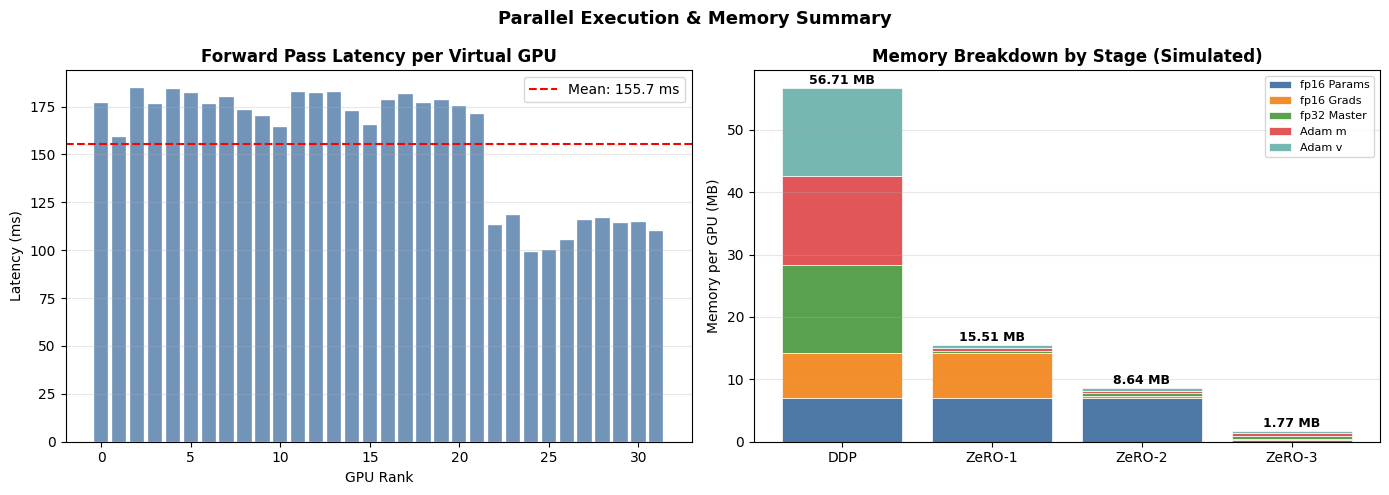

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Latency bar chart per GPU
ranks = [r[0] for r in results]
lats  = [r[1] for r in results]
ax1.bar(ranks, lats, color='#4e79a7', alpha=0.8, edgecolor='white', linewidth=0.3)
ax1.axhline(np.mean(lats), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(lats):.1f} ms')
ax1.set_xlabel('GPU Rank')
ax1.set_ylabel('Latency (ms)')
ax1.set_title('Forward Pass Latency per Virtual GPU', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Comprehensive memory summary
stage_names_short = ['DDP', 'ZeRO-1', 'ZeRO-2', 'ZeRO-3']
mem_components = ['params_fp16 (MB)', 'grads_fp16 (MB)', 'master_weights (MB)',
                  'opt_momentum (MB)', 'opt_variance (MB)']
comp_labels = ['fp16 Params', 'fp16 Grads', 'fp32 Master', 'Adam m', 'Adam v']

x = np.arange(len(logs))
bottoms = np.zeros(len(logs))
for comp, label, color in zip(mem_components, comp_labels, colors_stack):
    vals = np.array([log['memory_per_gpu_mb'].get(comp, 0) for log in logs])
    ax2.bar(x, vals, bottom=bottoms, label=label, color=color, edgecolor='white', linewidth=0.5)
    bottoms += vals

ax2.set_xticks(x)
ax2.set_xticklabels(stage_names_short)
ax2.set_ylabel('Memory per GPU (MB)')
ax2.set_title('Memory Breakdown by Stage (Simulated)', fontweight='bold')
ax2.legend(loc='upper right', fontsize=8)
ax2.grid(axis='y', alpha=0.3)
for i, total in enumerate(bottoms):
    ax2.text(i, total + 0.1, f'{total:.2f} MB', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Parallel Execution & Memory Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('zero_perf.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary Table

In [13]:
print("=" * 85)
print(f"{'ZERO STAGE COMPARISON SUMMARY':^85}")
print(f"Model: {total_params/1e6:.2f}M params | Cluster: {NUM_GPUS} virtual GPUs")
print("=" * 85)

header = f"{'Metric':<35} {'DDP':>10} {'ZeRO-1':>10} {'ZeRO-2':>10} {'ZeRO-3':>10}"
print(header)
print("-" * 85)

def row(label, vals, fmt='{:.2f}', suffix=''):
    parts = [f'{fmt.format(v)}{suffix}' for v in vals]
    print(f"{label:<35} {parts[0]:>10} {parts[1]:>10} {parts[2]:>10} {parts[3]:>10}")

total_mems = [sum(log['memory_per_gpu_mb'][k] for k in
               ['params_fp16 (MB)', 'grads_fp16 (MB)', 'master_weights (MB)',
                'opt_momentum (MB)', 'opt_variance (MB)']) for log in logs]

row('Total memory / GPU (MB)', total_mems)
row('Memory reduction vs DDP', [total_mems[0]/t for t in total_mems], fmt='{:.1f}', suffix='×')

print()
all_reduce_mb  = [log['comm_bytes'].get('all_reduce',  0)/1e6 for log in logs]
red_scat_mb    = [log['comm_bytes'].get('reduce_scatter',0)/1e6 for log in logs]
all_gather_mb  = [log['comm_bytes'].get('all_gather', 0)/1e6 for log in logs]
total_comm     = [a+r+g for a,r,g in zip(all_reduce_mb, red_scat_mb, all_gather_mb)]

row('All-Reduce (MB)',          all_reduce_mb,  fmt='{:.2f}')
row('Reduce-Scatter (MB)',      red_scat_mb,    fmt='{:.2f}')
row('All-Gather (MB)',          all_gather_mb,  fmt='{:.2f}')
row('Total comm per step (MB)', total_comm,     fmt='{:.2f}')

print()
print("What's sharded (1/N per GPU):")
sharding = [
    ('fp16 Parameters',  ['Full', 'Full',  'Full',  '1/N']),
    ('fp16 Gradients',   ['Full', 'Full',  '1/N',   '1/N']),
    ('fp32 Master Wts',  ['Full', '1/N',   '1/N',   '1/N']),
    ('Adam m & v',       ['Full', '1/N',   '1/N',   '1/N']),
]
for label, vals in sharding:
    print(f"  {label:<33} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10} {vals[3]:>10}")

print()
print("Extra collectives vs DDP:")
extras = [
    ('Backward comm',  ['All-Reduce', 'All-Reduce', 'Reduce-Scatter', 'Reduce-Scatter']),
    ('Post-opt comm',  ['None',       'All-Gather', 'All-Gather',     'None']),
    ('Forward comm',   ['None',       'None',       'None',           'All-Gather']),
]
for label, vals in extras:
    print(f"  {label:<33} {vals[0]:>10} {vals[1]:>10} {vals[2]:>10} {vals[3]:>10}")

print("=" * 85)
print(f"\nKey insight: ZeRO-3 achieves {total_mems[0]/total_mems[3]:.1f}× memory reduction with 32 GPUs.")
print(f"The trade-off: ZeRO-3 requires ALL-GATHER before every forward pass layer,")
print(f"adding {all_gather_mb[3]:.1f} MB of communication that DDP/ZeRO-1/ZeRO-2 don't need.")

                            ZERO STAGE COMPARISON SUMMARY                            
Model: 3.72M params | Cluster: 32 virtual GPUs
Metric                                     DDP     ZeRO-1     ZeRO-2     ZeRO-3
-------------------------------------------------------------------------------------
Total memory / GPU (MB)                  56.71      15.51       8.64       1.77
Memory reduction vs DDP                   1.0×       3.7×       6.6×      32.0×

All-Reduce (MB)                          14.40      14.40       0.00       0.00
Reduce-Scatter (MB)                       0.00       0.00       7.20       7.20
All-Gather (MB)                           0.00      14.40      14.40       7.20
Total comm per step (MB)                 14.40      28.80      21.60      14.40

What's sharded (1/N per GPU):
  fp16 Parameters                         Full       Full       Full        1/N
  fp16 Gradients                          Full       Full        1/N        1/N
  fp32 Master Wts            

## 13. Step Timing Analysis

We break each training step into its constituent phases and measure how long each takes across all four strategies. The canonical phases are:

| Phase | Description |
|-------|-------------|
| **Forward** | Compute logits (+ all-gather params for ZeRO-3) |
| **Backward** | Simulate gradient computation |
| **Grad Comm** | All-reduce (DDP/ZeRO-1) or Reduce-scatter (ZeRO-2/3) |
| **Optimizer** | Adam update + All-gather params (ZeRO-1/2) or local only (ZeRO-3) |

> **Note**: In this CPU simulation, communication is synchronous in-process tensor ops — wall times will not reflect real network latency. The *relative* overhead between stages is what matters.


In [14]:
# ── Canonical timing extraction ───────────────────────────────────────────
# Each simulate_*() log has a 'phases' list with (label, seconds) pairs.
# We map them to four canonical categories for cross-stage comparison.

def canonicalize_phases(log):
    """Return dict {canonical_label: ms} from a step log's phases list."""
    mapping = {
        'forward':               'Forward',
        'forward+all_gather':    'Forward\n(+AllGather)',
        'backward':              'Backward',
        'all_reduce':            'Grad Comm\n(AllReduce)',
        'reduce_scatter':        'Grad Comm\n(ReduceScatter)',
        'optimizer':             'Optimizer',
        'optimizer+all_gather':  'Optimizer\n(+AllGather)',
        'optimizer (local)':     'Optimizer\n(local)',
    }
    return {mapping.get(phase, phase): t * 1000 for phase, t in log['phases']}


# Consolidated canonical names (4 slots, same order for every stage)
SLOT_NAMES   = ['Forward', 'Backward', 'Grad Comm', 'Optimizer']
SLOT_COLORS  = ['#4e79a7', '#f28e2b', '#d62728',   '#59a14f']

def slot_times(log):
    """Collapse every phase into one of the 4 canonical slots (ms)."""
    phases = dict(log['phases'])  # label -> seconds
    fwd  = phases.get('forward',             phases.get('forward+all_gather',    0)) * 1000
    bwd  = phases.get('backward', 0) * 1000
    comm = phases.get('all_reduce',          phases.get('reduce_scatter',         0)) * 1000
    opt  = phases.get('optimizer',           phases.get('optimizer+all_gather',
                       phases.get('optimizer (local)', 0))) * 1000
    return {'Forward': fwd, 'Backward': bwd, 'Grad Comm': comm, 'Optimizer': opt}


stage_labels_short = ['DDP', 'ZeRO-1', 'ZeRO-2', 'ZeRO-3']
timing_by_stage = {lbl: slot_times(log) for lbl, log in zip(stage_labels_short, logs)}

# ── Timing table ─────────────────────────────────────────────────────────
print('=' * 70)
print(f'{"STEP TIMING BREAKDOWN (ms)":^70}')
print('=' * 70)
print(f'{"Phase":<20} {"DDP":>10} {"ZeRO-1":>10} {"ZeRO-2":>10} {"ZeRO-3":>10}')
print('-' * 70)
for slot in SLOT_NAMES:
    vals = [timing_by_stage[s][slot] for s in stage_labels_short]
    print(f'{slot:<20} {vals[0]:>9.2f}ms {vals[1]:>9.2f}ms {vals[2]:>9.2f}ms {vals[3]:>9.2f}ms')
print('-' * 70)
totals = {s: sum(timing_by_stage[s].values()) for s in stage_labels_short}
print(f'{"TOTAL STEP TIME":<20} {totals["DDP"]:>9.2f}ms {totals["ZeRO-1"]:>9.2f}ms '
      f'{totals["ZeRO-2"]:>9.2f}ms {totals["ZeRO-3"]:>9.2f}ms')
print('=' * 70)
print()
print('Phase notes:')
print('  DDP        Forward=compute only, GradComm=AllReduce, Optimizer=full copy')
print('  ZeRO-1     Forward=compute only, GradComm=AllReduce, Optimizer includes AllGather')
print('  ZeRO-2     Forward=compute only, GradComm=ReduceScatter, Optimizer includes AllGather')
print('  ZeRO-3     Forward includes AllGather, GradComm=ReduceScatter, Optimizer=local only')


                      STEP TIMING BREAKDOWN (ms)                      
Phase                       DDP     ZeRO-1     ZeRO-2     ZeRO-3
----------------------------------------------------------------------
Forward                  20.10ms      1.15ms      0.52ms     86.31ms
Backward                110.78ms     62.99ms     54.97ms     61.80ms
Grad Comm                79.86ms     65.77ms     29.18ms     33.16ms
Optimizer              1216.04ms    182.72ms    120.34ms     66.64ms
----------------------------------------------------------------------
TOTAL STEP TIME        1426.78ms    312.63ms    205.00ms    247.92ms

Phase notes:
  DDP        Forward=compute only, GradComm=AllReduce, Optimizer=full copy
  ZeRO-1     Forward=compute only, GradComm=AllReduce, Optimizer includes AllGather
  ZeRO-2     Forward=compute only, GradComm=ReduceScatter, Optimizer includes AllGather
  ZeRO-3     Forward includes AllGather, GradComm=ReduceScatter, Optimizer=local only


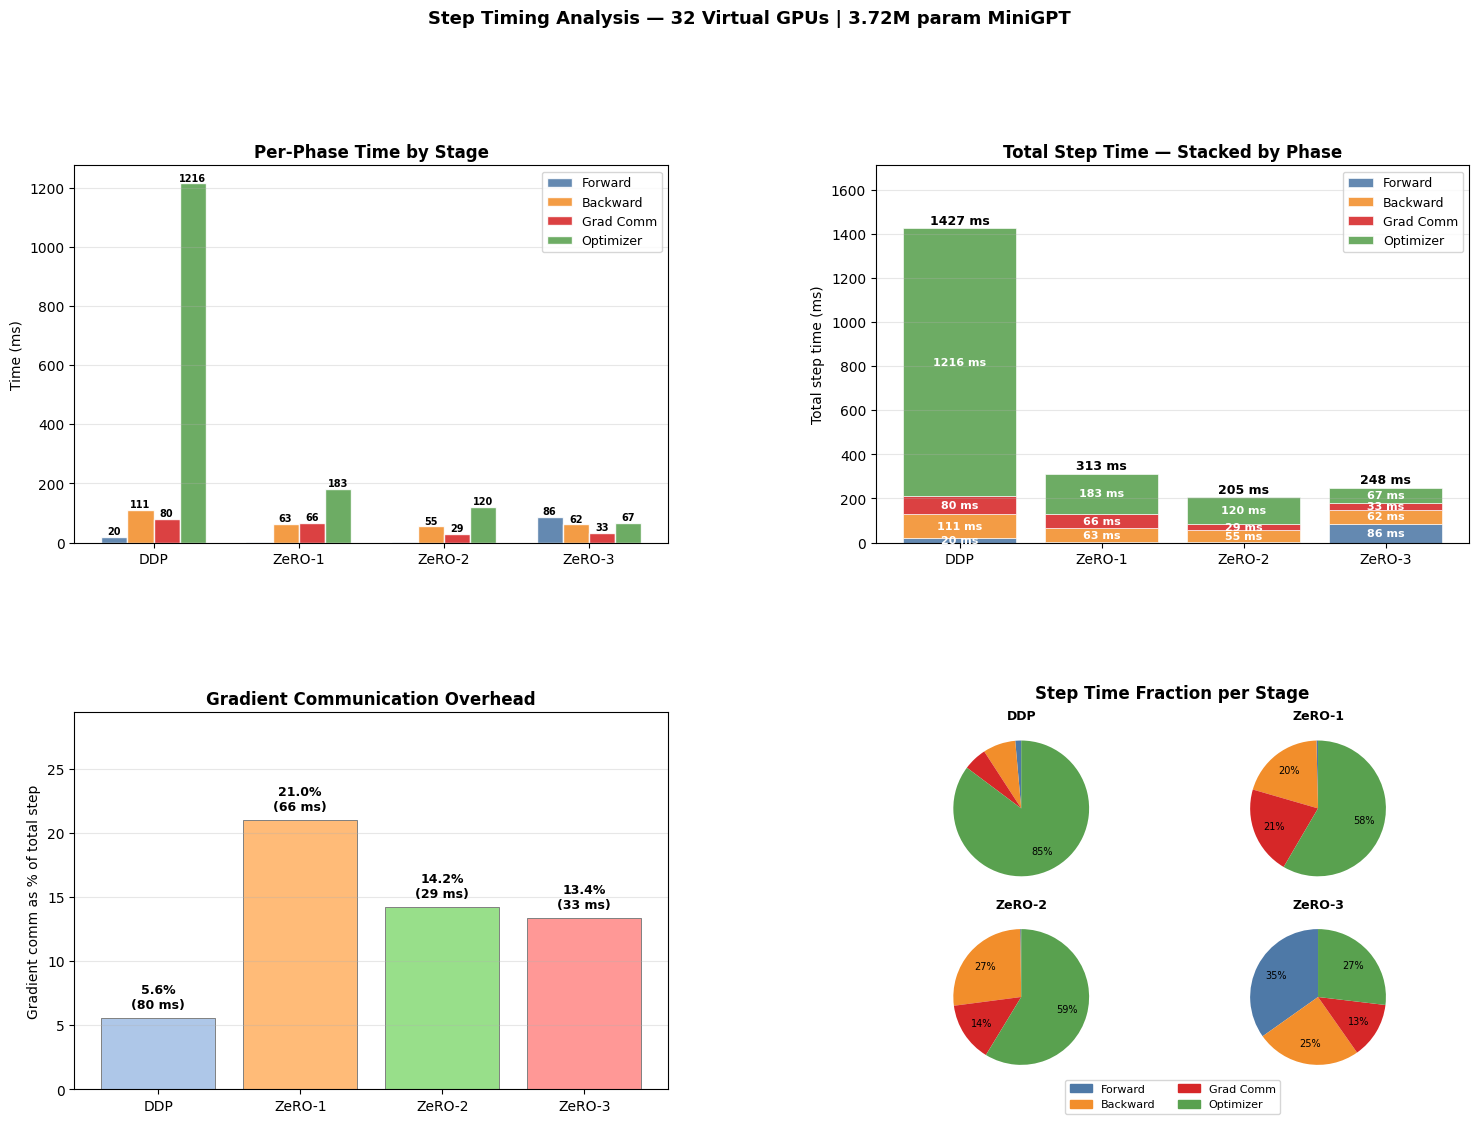

Saved: zero_timing.png


In [15]:
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Grouped bar — each phase side-by-side per stage ─────────────
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(len(stage_labels_short))
n_slots = len(SLOT_NAMES)
w = 0.18
offsets = np.linspace(-(n_slots-1)/2, (n_slots-1)/2, n_slots) * w
for i, (slot, color) in enumerate(zip(SLOT_NAMES, SLOT_COLORS)):
    vals = [timing_by_stage[s][slot] for s in stage_labels_short]
    bars = ax1.bar(x + offsets[i], vals, w, label=slot, color=color, alpha=0.88, edgecolor='white')
    for bar, v in zip(bars, vals):
        if v > 2:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{v:.0f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(stage_labels_short)
ax1.set_ylabel('Time (ms)')
ax1.set_title('Per-Phase Time by Stage', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: Stacked bar — total step time coloured by phase ──────────────
ax2 = fig.add_subplot(gs[0, 1])
bottoms2 = np.zeros(len(stage_labels_short))
for slot, color in zip(SLOT_NAMES, SLOT_COLORS):
    vals = np.array([timing_by_stage[s][slot] for s in stage_labels_short])
    ax2.bar(stage_labels_short, vals, bottom=bottoms2, label=slot,
            color=color, alpha=0.88, edgecolor='white', linewidth=0.5)
    for j, (v, b) in enumerate(zip(vals, bottoms2)):
        if v > 5:
            ax2.text(j, b + v/2, f'{v:.0f} ms', ha='center', va='center',
                     fontsize=8, color='white', fontweight='bold')
    bottoms2 += vals
for j, total in enumerate(bottoms2):
    ax2.text(j, total + 5, f'{total:.0f} ms', ha='center', va='bottom',
             fontsize=9, fontweight='bold')
ax2.set_ylabel('Total step time (ms)')
ax2.set_title('Total Step Time — Stacked by Phase', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, bottoms2.max() * 1.2)

# ── Panel 3: Communication time fraction ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
comm_ms   = np.array([timing_by_stage[s]['Grad Comm'] for s in stage_labels_short])
total_ms  = np.array(list(totals.values()))
comm_frac = comm_ms / total_ms * 100
bar_c = ['#aec7e8', '#ffbb78', '#98df8a', '#ff9896']
bars3 = ax3.bar(stage_labels_short, comm_frac, color=bar_c, edgecolor='gray', linewidth=0.7)
for bar, f, ms in zip(bars3, comm_frac, comm_ms):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{f:.1f}%\n({ms:.0f} ms)', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_ylabel('Gradient comm as % of total step')
ax3.set_title('Gradient Communication Overhead', fontsize=12, fontweight='bold')
ax3.set_ylim(0, comm_frac.max() * 1.4)
ax3.grid(axis='y', alpha=0.3)

# ── Panel 4: Pie charts — time fraction per stage ─────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
# Draw 4 mini pie charts in a 2×2 grid inside ax4
mini_axes_pos = [(0.02, 0.52, 0.45, 0.45),   # DDP   top-left
                 (0.52, 0.52, 0.45, 0.45),   # ZeRO-1 top-right
                 (0.02, 0.02, 0.45, 0.45),   # ZeRO-2 bottom-left
                 (0.52, 0.02, 0.45, 0.45)]   # ZeRO-3 bottom-right
for i, (stage, pos) in enumerate(zip(stage_labels_short, mini_axes_pos)):
    inset = ax4.inset_axes(pos)
    vals  = [timing_by_stage[stage][s] for s in SLOT_NAMES]
    wedge_colors = SLOT_COLORS
    inset.pie(vals, colors=wedge_colors, startangle=90,
              autopct=lambda p: f'{p:.0f}%' if p > 8 else '',
              pctdistance=0.7, textprops={'fontsize': 7})
    inset.set_title(stage, fontsize=9, fontweight='bold', pad=3)
legend_patches2 = [mpatches.Patch(color=c, label=s) for c, s in zip(SLOT_COLORS, SLOT_NAMES)]
ax4.legend(handles=legend_patches2, loc='lower center', ncol=2,
           fontsize=8, bbox_to_anchor=(0.5, -0.08))
ax4.set_title('Step Time Fraction per Stage', fontsize=12, fontweight='bold', pad=10)

fig.suptitle(f'Step Timing Analysis — {NUM_GPUS} Virtual GPUs | {total_params/1e6:.2f}M param MiniGPT',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('zero_timing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: zero_timing.png')


## 14. Communication Build-up: How We Go from P → 2P → 3P

Let **P = one model-sized all-reduce** (DDP's baseline communication). Each ZeRO stage adds or replaces collectives:

| Stage | Forward | Backward | Post-Opt | Total |
|-------|---------|----------|----------|-------|
| DDP | — | All-Reduce (2Ψ) | — | **2Ψ = 2P** |
| ZeRO-1 | — | All-Reduce (2Ψ) | All-Gather (Ψ) | **3Ψ = 3P** |
| ZeRO-2 | — | Reduce-Scatter (Ψ) | All-Gather (Ψ) | **2Ψ = 2P** |
| ZeRO-3 | All-Gather (Ψ) | Reduce-Scatter (Ψ) + All-Gather (Ψ) | — | **3Ψ = 3P** |

Where **Ψ** = one full model copy (bytes). A ring all-reduce = reduce-scatter + all-gather = Ψ + Ψ = **2Ψ**.

> Key insight: ZeRO-2 keeps the **same** communication as DDP (2P) while cutting memory 6×.
> ZeRO-1 and ZeRO-3 cost **3P** — extra overhead from an additional all-gather.


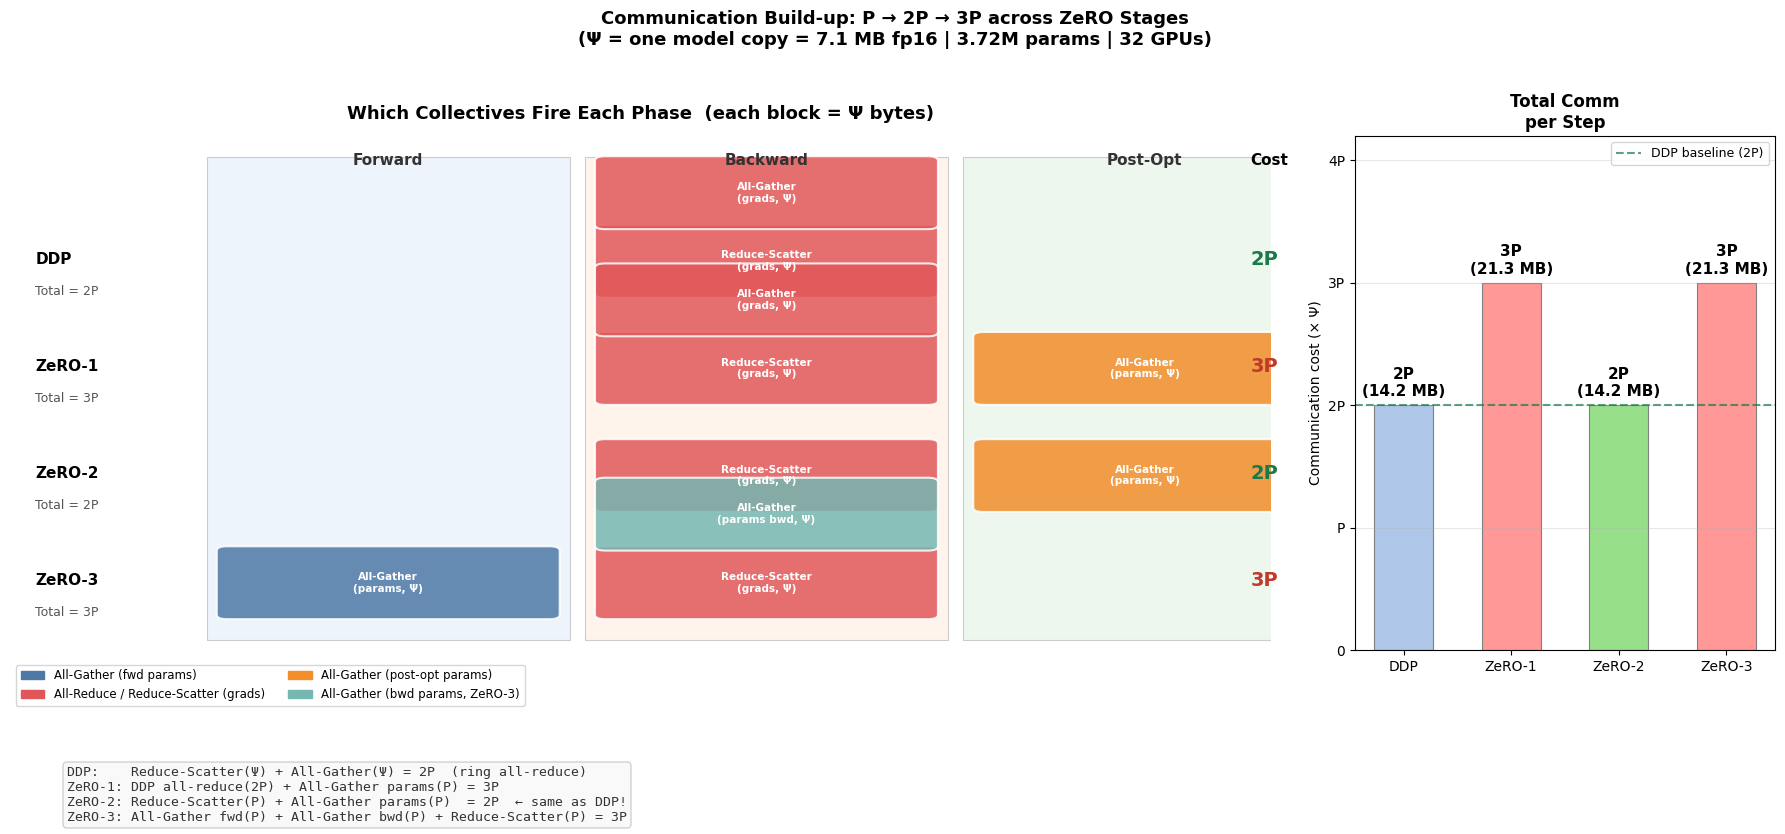

Saved: zero_comm_buildup.png


In [16]:
# ── Communication build-up diagram ───────────────────────────────────────
# Ψ = one model copy in fp16 (bytes). We express all volumes in units of Ψ.
# Ring all-reduce = reduce-scatter (Ψ) + all-gather (Ψ) = 2Ψ.

PSI = 2 * total_params  # fp16: 2 bytes/param — Ψ in bytes
PSI_MB = PSI / 1024**2

# Each collective defined as (phase, label, volume_in_psi, colour)
STAGES_COMM = {
    'DDP': [
        ('Backward', 'Reduce-Scatter\n(grads, Ψ)',  1.0, '#e15759'),
        ('Backward', 'All-Gather\n(grads, Ψ)',      1.0, '#e15759'),
    ],
    'ZeRO-1': [
        ('Backward', 'Reduce-Scatter\n(grads, Ψ)',  1.0, '#e15759'),
        ('Backward', 'All-Gather\n(grads, Ψ)',      1.0, '#e15759'),
        ('Post-Opt', 'All-Gather\n(params, Ψ)',     1.0, '#f28e2b'),
    ],
    'ZeRO-2': [
        ('Backward', 'Reduce-Scatter\n(grads, Ψ)',  1.0, '#e15759'),
        ('Post-Opt', 'All-Gather\n(params, Ψ)',     1.0, '#f28e2b'),
    ],
    'ZeRO-3': [
        ('Forward',  'All-Gather\n(params, Ψ)',     1.0, '#4e79a7'),
        ('Backward', 'Reduce-Scatter\n(grads, Ψ)',  1.0, '#e15759'),
        ('Backward', 'All-Gather\n(params bwd, Ψ)', 1.0, '#76b7b2'),
    ],
}

STAGE_ORDER  = ['DDP', 'ZeRO-1', 'ZeRO-2', 'ZeRO-3']
TOTAL_PSI    = {s: sum(c[2] for c in v) for s, v in STAGES_COMM.items()}
PHASE_ORDER  = ['Forward', 'Backward', 'Post-Opt']
PHASE_BG     = {'Forward': '#edf4fb', 'Backward': '#fef4ec', 'Post-Opt': '#edf7ed'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [3, 1]})

# ── Left: horizontal swim-lane diagram ───────────────────────────────────
ax = axes[0]
ax.set_xlim(-0.5, 4.5)
ax.set_ylim(-0.3, len(STAGE_ORDER) + 0.5)
ax.axis('off')
ax.set_title('Which Collectives Fire Each Phase  (each block = Ψ bytes)',
             fontsize=13, fontweight='bold', pad=12)

# Phase column headers
col_x = {'Forward': 1.0, 'Backward': 2.5, 'Post-Opt': 4.0}
for phase, x in col_x.items():
    ax.text(x, len(STAGE_ORDER) + 0.2, phase,
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            color='#333333')
    rect = plt.Rectangle((x - 0.72, -0.2), 1.44, len(STAGE_ORDER) + 0.5,
                          facecolor=PHASE_BG[phase], edgecolor='#cccccc',
                          linewidth=0.8, zorder=0)
    ax.add_patch(rect)

# Stage rows
for row, stage in enumerate(STAGE_ORDER):
    y = len(STAGE_ORDER) - 1 - row

    # Stage label
    total_p = TOTAL_PSI[stage]
    ax.text(-0.4, y + 0.35, stage, ha='left', va='center',
            fontsize=11, fontweight='bold')
    ax.text(-0.4, y + 0.05, f'Total = {total_p:.0f}P',
            ha='left', va='center', fontsize=9, color='#555555')

    # Place each collective block
    phase_count = {'Forward': 0, 'Backward': 0, 'Post-Opt': 0}
    for phase, label, vol, color in STAGES_COMM[stage]:
        cx = col_x[phase]
        offset = (phase_count[phase] - 0.5) * 0.68
        bx = cx - 0.62 + phase_count[phase] * 0.0  # stack vertically within cell
        by = y + 0.02 + phase_count[phase] * 0.0

        # Draw block
        block_h = 0.60
        block_w = 1.28
        rect2 = mpatches.FancyBboxPatch(
            (cx - block_w/2, y + 0.03 + phase_count[phase] * (block_h + 0.04)),
            block_w, block_h,
            boxstyle='round,pad=0.04',
            facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.85, zorder=2
        )
        ax.add_patch(rect2)
        mid_y = y + 0.03 + phase_count[phase] * (block_h + 0.04) + block_h / 2
        ax.text(cx, mid_y, label, ha='center', va='center',
                fontsize=7.5, color='white', fontweight='bold', zorder=3)
        phase_count[phase] += 1

# Add bracket / total annotation on the right
for row, stage in enumerate(STAGE_ORDER):
    y = len(STAGE_ORDER) - 1 - row
    total_p = TOTAL_PSI[stage]
    color = '#1a7a4a' if total_p <= 2 else '#c0392b'
    ax.text(4.42, y + 0.35, f'{total_p:.0f}P',
            ha='left', va='center', fontsize=14, fontweight='bold', color=color)

ax.text(4.42, len(STAGE_ORDER) + 0.2, 'Cost',
        ha='left', va='bottom', fontsize=11, fontweight='bold')

# Legend
leg_patches = [
    mpatches.Patch(color='#4e79a7', label='All-Gather (fwd params)'),
    mpatches.Patch(color='#e15759', label='All-Reduce / Reduce-Scatter (grads)'),
    mpatches.Patch(color='#f28e2b', label='All-Gather (post-opt params)'),
    mpatches.Patch(color='#76b7b2', label='All-Gather (bwd params, ZeRO-3)'),
]
ax.legend(handles=leg_patches, loc='lower left', fontsize=8.5,
          bbox_to_anchor=(0.0, -0.12), ncol=2)

# ── Right: bar chart of total comm cost in P units ────────────────────────
ax2 = axes[1]
psi_vals  = [TOTAL_PSI[s] for s in STAGE_ORDER]
bar_cols  = ['#aec7e8', '#ff9896', '#98df8a', '#ff9896']
bars = ax2.bar(STAGE_ORDER, psi_vals, color=bar_cols, edgecolor='gray',
               linewidth=0.8, width=0.55)
for bar, v in zip(bars, psi_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{v:.0f}P\n({v*PSI_MB:.1f} MB)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.axhline(2, color='#1a7a4a', linestyle='--', linewidth=1.5, alpha=0.7,
            label='DDP baseline (2P)')
ax2.set_ylim(0, 4.2)
ax2.set_ylabel('Communication cost (× Ψ)', fontsize=10)
ax2.set_title('Total Comm\nper Step', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(['0', 'P', '2P', '3P', '4P'])

# ── Annotation: how each stage is built up ────────────────────────────────
notes = [
    'DDP:    Reduce-Scatter(Ψ) + All-Gather(Ψ) = 2P  (ring all-reduce)',
    'ZeRO-1: DDP all-reduce(2P) + All-Gather params(P) = 3P',
    'ZeRO-2: Reduce-Scatter(P) + All-Gather params(P)  = 2P  ← same as DDP!',
    'ZeRO-3: All-Gather fwd(P) + All-Gather bwd(P) + Reduce-Scatter(P) = 3P',
]
fig.text(0.04, -0.06, '\n'.join(notes), fontsize=9.5, family='monospace',
         va='top', color='#333333',
         bbox=dict(boxstyle='round', facecolor='#f9f9f9', edgecolor='#cccccc', alpha=0.9))

fig.suptitle(f'Communication Build-up: P → 2P → 3P across ZeRO Stages\n'
             f'(Ψ = one model copy = {PSI_MB:.1f} MB fp16 | {total_params/1e6:.2f}M params | {NUM_GPUS} GPUs)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('zero_comm_buildup.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: zero_comm_buildup.png')


### Measured Simulation: Timing Each Collective on the Virtual GPU Cluster

We isolate every communication collective used in each stage, run it N_TRIALS times on the live virtual cluster, and measure wall time. This gives an empirical P → 2P → 3P curve from our CPU simulation — the *shape* mirrors what you'd see on real hardware (even though absolute latencies are CPU-bound, not network-bound).


Timing collectives on 32 virtual GPUs (Ψ = 7.43 MB fp16) · 5 trials each

  Reduce-Scatter (Ψ):    10.90 ± 0.98 ms
  All-Gather     (Ψ):    45.67 ± 16.68 ms
  All-Reduce  (2Ψ):      25.12 ± 3.02 ms

Measured comm time per stage:
  (1P ≈ 12.56 ms,  DDP = 2P = 25.12 ms)
  DDP     :   25.12 ms  ≈ 2.00P
  ZeRO-1  :   70.78 ms  ≈ 5.64P
  ZeRO-2  :   56.57 ms  ≈ 4.50P
  ZeRO-3  :  102.24 ms  ≈ 8.14P


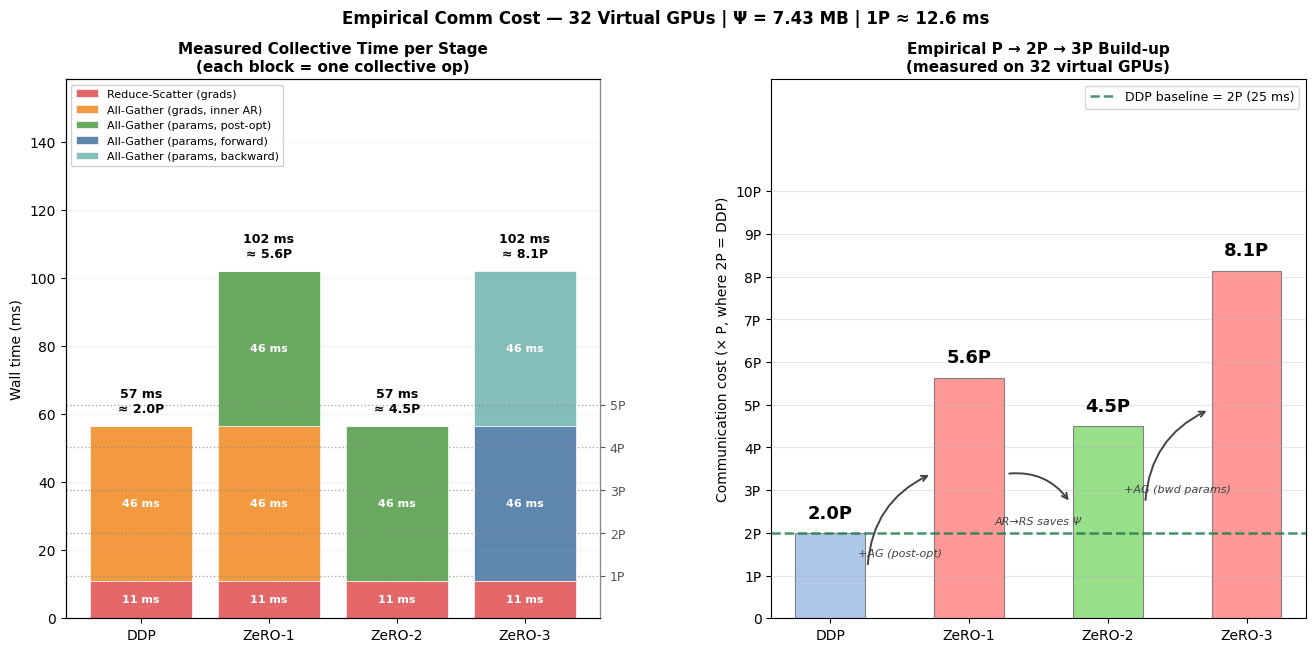

Saved: zero_comm_measured.png


In [17]:
N_TRIALS = 5  # runs per collective to average out noise

def time_collective(fn, *args, n=N_TRIALS):
    """Run fn(*args) N times, return mean wall time in ms."""
    times = []
    for _ in range(n):
        cluster.comm_bytes.clear()
        t0 = time.perf_counter()
        fn(*args)
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times)), float(np.std(times))

# Full-model fp16 tensors per GPU
fake_grads  = [torch.randn(total_params, dtype=torch.float16) * 0.01
               for _ in range(NUM_GPUS)]
# fp32 shards (1/N per GPU)
shard_size  = math.ceil(total_params / NUM_GPUS)
fake_shards = [torch.randn(shard_size, dtype=torch.float32) * 0.01
               for _ in range(NUM_GPUS)]

print(f'Timing collectives on {NUM_GPUS} virtual GPUs '
      f'(Ψ = {total_params*2/1e6:.2f} MB fp16) · {N_TRIALS} trials each')

t_ar, e_ar = time_collective(cluster.all_reduce_sum, fake_grads)
t_rs, e_rs = time_collective(cluster.reduce_scatter, fake_grads)
t_ag, e_ag = time_collective(cluster.all_gather,     fake_shards, total_params)

print(f'\n  Reduce-Scatter (Ψ):  {t_rs:7.2f} ± {e_rs:.2f} ms')
print(f'  All-Gather     (Ψ):  {t_ag:7.2f} ± {e_ag:.2f} ms')
print(f'  All-Reduce  (2Ψ):    {t_ar:7.2f} ± {e_ar:.2f} ms')

# Stage comm budgets
measured_comm_ms = {
    'DDP':    t_ar,
    'ZeRO-1': t_ar + t_ag,
    'ZeRO-2': t_rs + t_ag,
    'ZeRO-3': t_ag + t_rs + t_ag,
}
breakdown = {
    'DDP':    {'RS (grads)': t_rs, 'AG (grads→AR)': t_ag, 'AG (post-opt)': 0,    'AG (fwd)': 0,    'AG (bwd)': 0},
    'ZeRO-1': {'RS (grads)': t_rs, 'AG (grads→AR)': t_ag, 'AG (post-opt)': t_ag, 'AG (fwd)': 0,    'AG (bwd)': 0},
    'ZeRO-2': {'RS (grads)': t_rs, 'AG (grads→AR)': 0,    'AG (post-opt)': t_ag, 'AG (fwd)': 0,    'AG (bwd)': 0},
    'ZeRO-3': {'RS (grads)': t_rs, 'AG (grads→AR)': 0,    'AG (post-opt)': 0,    'AG (fwd)': t_ag, 'AG (bwd)': t_ag},
}

one_P  = t_ar / 2          # 1P = half of DDP (= one ring-allreduce half = Ψ)
ddp_ms = measured_comm_ms['DDP']

print('\nMeasured comm time per stage:')
print(f'  (1P ≈ {one_P:.2f} ms,  DDP = 2P = {ddp_ms:.2f} ms)')
stage_order = ['DDP', 'ZeRO-1', 'ZeRO-2', 'ZeRO-3']
norm_vals   = np.array([measured_comm_ms[s] / one_P for s in stage_order])
for s, ms, nv in zip(stage_order, [measured_comm_ms[s] for s in stage_order], norm_vals):
    print(f'  {s:<8}: {ms:7.2f} ms  ≈ {nv:.2f}P')

# ── Chart ─────────────────────────────────────────────────────────────────
STACK_KEYS   = ['RS (grads)', 'AG (grads→AR)', 'AG (post-opt)', 'AG (fwd)', 'AG (bwd)']
STACK_COLORS = ['#e15759', '#f28e2b', '#59a14f', '#4e79a7', '#76b7b2']
STACK_LABELS = ['Reduce-Scatter (grads)', 'All-Gather (grads, inner AR)',
                'All-Gather (params, post-opt)',
                'All-Gather (params, forward)', 'All-Gather (params, backward)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.subplots_adjust(top=0.88, wspace=0.32)

# ── Panel 1: stacked ms ───────────────────────────────────────────────────
bottoms = np.zeros(4)
for key, color, label in zip(STACK_KEYS, STACK_COLORS, STACK_LABELS):
    vals = np.array([breakdown[s][key] for s in stage_order])
    ax1.bar(stage_order, vals, bottom=bottoms,
            color=color, label=label, edgecolor='white', linewidth=0.5, alpha=0.9)
    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > one_P * 0.15:          # only label if block is tall enough to read
            ax1.text(j, b + v / 2, f'{v:.0f} ms',
                     ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottoms += vals

# Horizontal P-unit reference lines — bold, coloured, clearly labelled
max_ms = bottoms.max()
p_ticks = [p for p in range(1, 6) if p * one_P <= max_ms * 1.05]
line_colors = {1: '#2196F3', 2: '#4CAF50', 3: '#F44336', 4: '#9C27B0', 5: '#FF9800'}
for p in p_ticks:
    ax1.axhline(p * one_P, color=line_colors[p], linestyle='--', linewidth=2.2, alpha=0.9, zorder=5)

# Top labels — placed well above the tallest bar
y_top = max_ms * 1.55      # extra ceiling so two-line labels fit
ax1.set_ylim(0, y_top)
for j, (total, nv) in enumerate(zip(bottoms, norm_vals)):
    ax1.text(j, total + max_ms * 0.03,
             f'{total:.0f} ms\n≈ {nv:.1f}P',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Secondary y-axis with P labels aligned to ms values
ax1b = ax1.twinx()
ax1b.set_ylim(0, y_top)
ax1b.set_yticks([p * one_P for p in p_ticks])
ax1b.set_yticklabels([f'{p}P' for p in p_ticks], fontsize=9, color='#555555')
ax1b.tick_params(axis='y', colors='#555555')
ax1b.spines['right'].set_color('#888888')

ax1.set_ylabel('Wall time (ms)')
ax1.set_title('Measured Collective Time per Stage\n(each block = one collective op)',
              fontsize=11, fontweight='bold')
ax1.legend(loc='upper left', fontsize=8, framealpha=0.9)
ax1.grid(axis='y', alpha=0.15)

# ── Panel 2: normalised P units ───────────────────────────────────────────
bar_colors2 = ['#aec7e8', '#ff9896', '#98df8a', '#ff9896']
bars2 = ax2.bar(stage_order, norm_vals, color=bar_colors2,
                edgecolor='gray', linewidth=0.8, width=0.5)

# Value labels — placed just above each bar
y2_top = norm_vals.max() * 1.55
ax2.set_ylim(0, y2_top)
for bar, v in zip(bars2, norm_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + y2_top * 0.02,
             f'{v:.1f}P', ha='center', va='bottom', fontsize=13, fontweight='bold')

# P-unit reference lines on panel 2 — bold, coloured
for p in range(1, max_p + 1):
    if p <= norm_vals.max() * 1.1:
        ax2.axhline(p, color=line_colors.get(p, '#888888'), linestyle='--',
                    linewidth=2.2, alpha=0.85, zorder=5)
        ax2.text(3.52, p + y2_top * 0.015, f'{p}P',
                 fontsize=10, fontweight='bold', color=line_colors.get(p, '#888888'),
                 va='bottom', ha='left')
# DDP reference line (highlight 2P separately)
ax2.axhline(2, color='#1a7a4a', linestyle='-', linewidth=3.0, alpha=0.5,
            label=f'DDP baseline = 2P ({ddp_ms:.0f} ms)')

# Dynamic integer P ticks up to ceil of max
max_p = math.ceil(norm_vals.max()) + 1
ax2.set_yticks(range(0, max_p + 1))
ax2.set_yticklabels([f'{p}P' if p > 0 else '0' for p in range(0, max_p + 1)], fontsize=10)

# Curved arrows between bars — kept in lower half of chart to avoid label overlap
ann_x = [0, 1, 2, 3]
for src_i, dst_i, note in [
    (0, 1, '+AG (post-opt)'),
    (1, 2, 'AR→RS saves Ψ'),
    (2, 3, '+AG (bwd params)'),
]:
    y_src = norm_vals[src_i]
    y_dst = norm_vals[dst_i]
    # Arrow tip at bar top; anchor at 60% of bar height so arrow stays inside chart
    ax2.annotate('',
        xy=(ann_x[dst_i] - 0.27, y_dst * 0.6),
        xytext=(ann_x[src_i] + 0.27, y_src * 0.6),
        arrowprops=dict(arrowstyle='->', color='#444444', lw=1.4,
                        connectionstyle='arc3,rad=-0.3'))
    mid_x = (ann_x[src_i] + ann_x[dst_i]) / 2
    mid_y = (y_src + y_dst) / 2 * 0.6 - norm_vals.max() * 0.08
    ax2.text(mid_x, max(mid_y, 0.1), note,
             ha='center', va='top', fontsize=8, color='#444444', style='italic')

ax2.set_ylabel('Communication cost (× P, where 2P = DDP)', fontsize=10)
ax2.set_title('Empirical P → 2P → 3P Build-up\n(measured on 32 virtual GPUs)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(axis='y', alpha=0.3)

fig.suptitle(
    f'Empirical Comm Cost — {NUM_GPUS} Virtual GPUs | '
    f'Ψ = {total_params*2/1e6:.2f} MB | 1P ≈ {one_P:.1f} ms',
    fontsize=12, fontweight='bold')
plt.savefig('zero_comm_measured.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: zero_comm_measured.png')


## 15. Key Takeaways

### Memory
| Stage | What's stored per GPU | Memory formula |
|-------|----------------------|----------------|
| DDP | Full P + G + OPT | 16Ψ |
| ZeRO-1 | Full P + G + OPT/N | 2Ψ + 2Ψ + 12Ψ/N |
| ZeRO-2 | Full P + G/N + OPT/N | 2Ψ + 14Ψ/N |
| ZeRO-3 | P/N + G/N + OPT/N | 16Ψ/N |

Where Ψ = number of model parameters, N = number of GPUs.

### Communication
- **DDP**: 1 All-Reduce (2Ψ bytes per step)
- **ZeRO-1**: 1 All-Reduce + 1 All-Gather (3Ψ bytes per step)
- **ZeRO-2**: 1 Reduce-Scatter + 1 All-Gather (2Ψ bytes per step) — same as DDP!
- **ZeRO-3**: 1 All-Gather (fwd) + 1 Reduce-Scatter (bwd) = 3Ψ bytes per step

### When to use which
- **DDP**: Small models that fit in GPU memory. Lowest latency.
- **ZeRO-1**: Model fits but optimizer states are the bottleneck.
- **ZeRO-2**: Gradients accumulation of large models. Good balance.
- **ZeRO-3**: Models that literally don't fit on a single GPU (LLMs, VLMs). Higher communication overhead.